In [1]:
from qiskit import QuantumCircuit
import qiskit.quantum_info as qi
from IPython.display import display, Latex
import sympy as sp

qc = QuantumCircuit(2) #default kubit di quantum circuit = 0
qc.h([0, 1])
qc.draw()


┌───┐
q_0: ┤ H ├
     ├───┤
q_1: ┤ H ├
     └───┘

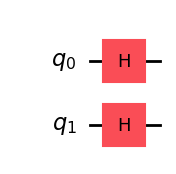

In [2]:
qc.draw('mpl')


In [3]:
psi = qi.Statevector(qc)
psi.draw('latex')
#hasilnya merupakan tensor dari H|0|

<IPython.core.display.Latex object>

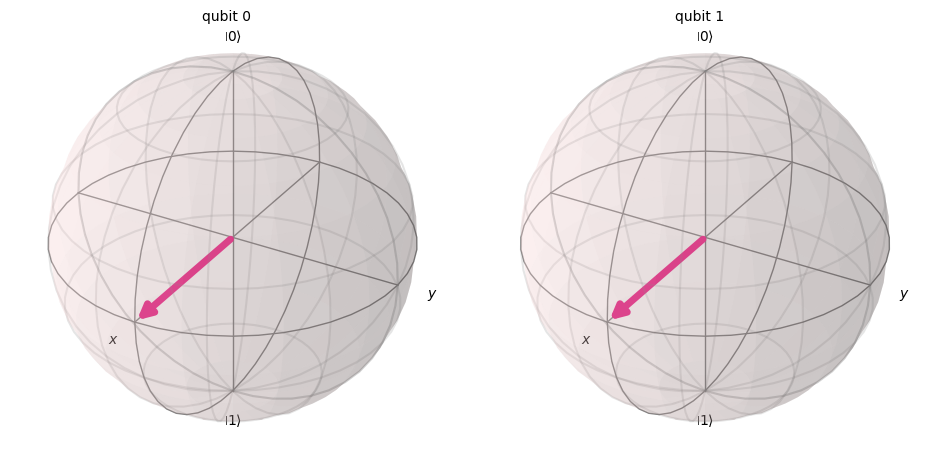

In [4]:
#gambar pakai bloch
psi.draw('bloch') #awalnya kubit bernilai 0, dikenakan Hadamard jd state +

In [5]:
#menghitung peluang
probs = psi.probabilities()
print(probs)

[0.25 0.25 0.25 0.25]


In [6]:
#mengukur psi sebanyak 1024 dan hasilnya bisa beda" karena probabilistik
counts = psi.sample_counts(shots=1024) 
print(counts)
#artinya kubit 00 muncul sebanyak 251 kali dst

{np.str_('00'): np.int64(278), np.str_('01'): np.int64(257), np.str_('10'): np.int64(251), np.str_('11'): np.int64(238)}


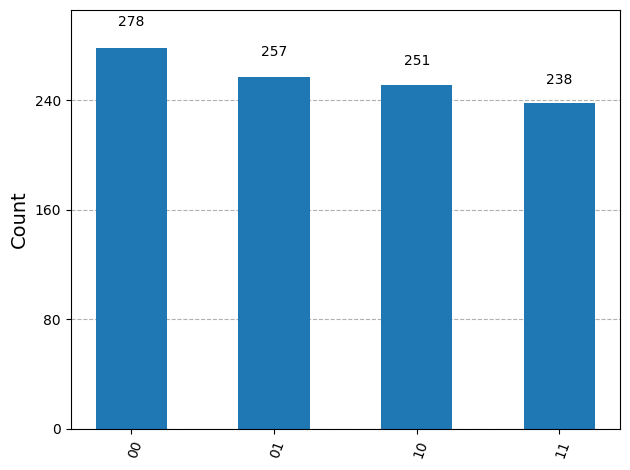

In [7]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

In [8]:
#algoritma counts itu bisa disimpan dengan
samples = psi.sample_memory(shots=5)
print(samples)

['01' '10' '01' '01' '00']


In [9]:
#mengukur nilai harap dari suatu operator
#sparse pauli op digunakan utk membuat operator dlm kombinasi linier matriks pauli
O = qi.SparsePauliOp(['ZZ', 'XX', 'II'], [0.1, -0.3, 0.5]) # O = a(ZZ)*tensor produk dari matriks identitas Z + bXX + cII
O.to_operator()

Operator([[ 0.6+0.j,  0. +0.j,  0. +0.j, -0.3+0.j],
          [ 0. +0.j,  0.4+0.j, -0.3+0.j,  0. +0.j],
          [ 0. +0.j, -0.3+0.j,  0.4+0.j,  0. +0.j],
          [-0.3+0.j,  0. +0.j,  0. +0.j,  0.6+0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


In [10]:
#untuk mengukur nilai harap ditentukan variabel
O_h = psi.expectation_value(O)
print(O_h)

(0.1999999999999999+0j)


### Membuat Sirkuit Kuantum Beneran ###

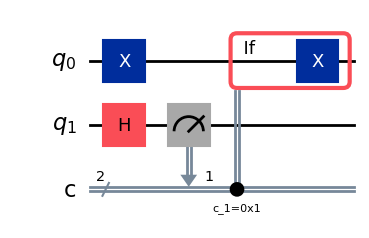

In [11]:
qc = QuantumCircuit(2,2) #2 yg pertama kubit, 2 yg ke2 klasik
qc.h(1)
qc.measure(1,1) #indeks pertama kubit, indeks ke2 hasil pengukurannya
qc.x(0) # x = rotasi arah sb x di bola bloch
with qc.if_test((1,1)): #jika pengukuran q1 menghasilkan 1 makan q0 berlaku
    qc.x(0)
qc.draw('mpl')


In [17]:
qi.Statevector(qc)

QiskitError: 'Cannot apply instruction with classical bits: measure'

### Simulasi Sirkuit Kuantum dengan AerSimulator ###

In [18]:
#untuk menampilkan statevector gabisa pakai qi.Statevector(qc) karena quantum info yg kita input 
# itu kubit dan gaboleh ada klasik nya

In [19]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator #Simulator yg dijalankan pakai qiskit, simulator berguna untuk menjalankan algoritma

simulator_basic = AerSimulator()

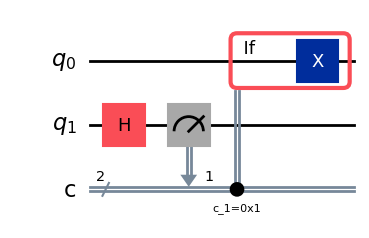

In [20]:
qc = QuantumCircuit(2,2)
qc.h(1)
qc.measure(1,1)
with qc.if_test((1,1)): #jika pengukuran q1 menghasilkan 1 makan q0 berlaku
    qc.x(0)
qc.draw('mpl')

In [21]:
#menjalankan simulator selama berapa kali
job = simulator_basic.run(qc,shots=1024) #dikasih tugas
result = job.result()
print(result)

Result(backend_name='aer_simulator', backend_version='0.17.2', job_id='59238628-b46b-474e-932c-5df726f01dd1', success=True, results=[ExperimentResult(shots=1024, success=True, meas_level=2, data=ExperimentResultData(counts={'0x0': 494, '0x2': 530}), header={'creg_sizes': [['c', 2]], 'global_phase': 0.0, 'memory_slots': 2, 'n_qubits': 2, 'name': 'circuit-58', 'qreg_sizes': [['q', 2]], 'metadata': {}}, status=DONE, seed_simulator=3492398371, metadata={'batched_shots_optimization': False, 'required_memory_mb': 0, 'method': 'stabilizer', 'active_input_qubits': [1], 'device': 'CPU', 'remapped_qubits': True, 'num_qubits': 1, 'num_clbits': 2, 'time_taken': 0.0853921, 'sample_measure_time': 0.0023378, 'input_qubit_map': [[1, 0]], 'max_memory_mb': 3918, 'measure_sampling': True, 'noise': 'ideal', 'parallel_shots': 1, 'parallel_state_update': 4, 'runtime_parameter_bind': False, 'num_bind_params': 1, 'fusion': {'enabled': False}}, time_taken=0.0853921)], date=2026-02-16T10:27:04.595341, status=CO

### Transpile ### 
Menerjemahkan algoritma kita ke bahasa gerbang

C:\Users\safira\AppData\Local\Temp\ipykernel_13012\3277256873.py:4: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(3), range(3)) #dikenakan QFT semua


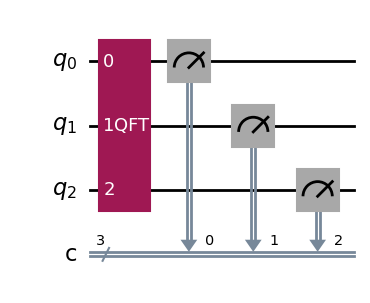

In [22]:
from qiskit.circuit.library import QFT

qc = QuantumCircuit(3,3)
qc.append(QFT(3), range(3)) #dikenakan QFT semua
qc.measure(range(3), range(3))
qc.draw('mpl')

In [23]:
job = simulator_basic.run(qc, shots = 1024)


In [24]:
#kalau gabisa import transpile
from qiskit import transpile

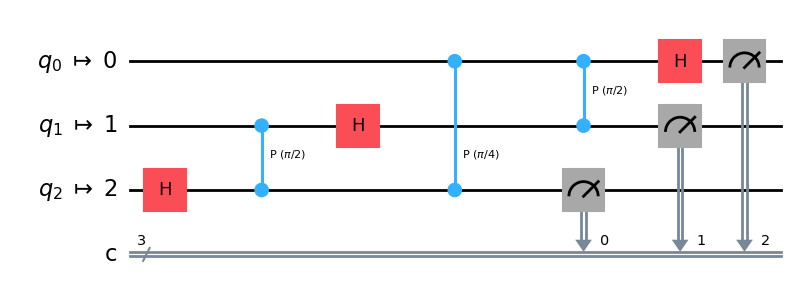

In [26]:
qc_t = transpile(qc, backend=simulator_basic)
qc_t.draw('mpl')

In [31]:
job = simulator_basic.run(qc_t, shots=1024)
result = job.result()
counts = result.get_counts() #result nya dicacah
print(counts)

{'011': 125, '001': 130, '101': 136, '010': 128, '100': 124, '110': 136, '111': 124, '000': 121}


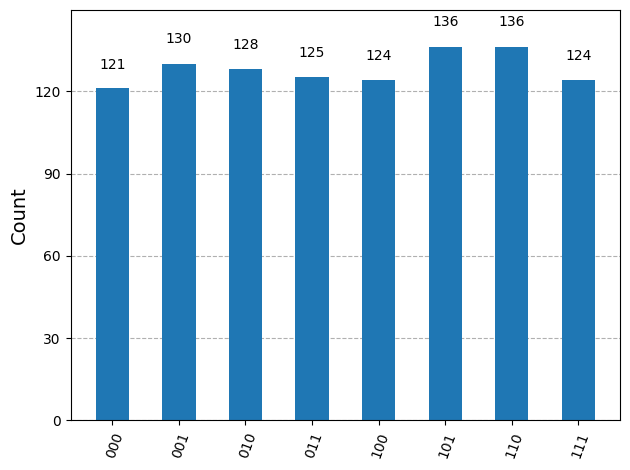

In [32]:
from qiskit.visualization import plot_histogram
plot_histogram(counts)

provider = penyedia, sesuatu yg kita minta untk melakukan simulasi
quantum_info berguna utk mencari statevector atau density matrix dr output circuit, tidak bisa dilakukan utk circuit yg besar dan terdapat bit klasik serta pengukuran di tengah.